# <u>Deriving Employee Age from Birthdate.

- ***STEP 1:*** Add an `age` column to the `hr` table.

```sql
ALTER TABLE hr
ADD COLUMN age INT;
```

```sql
SELECT age FROM hr;
```

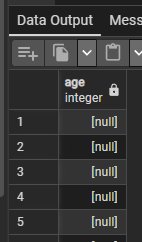

- ***STEP 2:*** Populate the `age` column by calculating age from `birthdate`.

```sql
UPDATE hr
SET age = EXTRACT(YEAR FROM AGE(CURRENT_DATE, birthdate));
```

```sql
SELECT birthdate, age FROM hr;
```

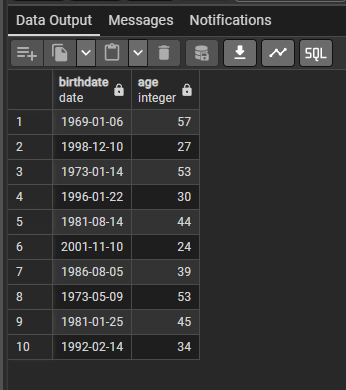

---

# <u>Age Range Analysis:

```sql
SELECT
	MIN(age) AS minimum_age,
	MAX(age) AS maximum_age
FROM hr;
```

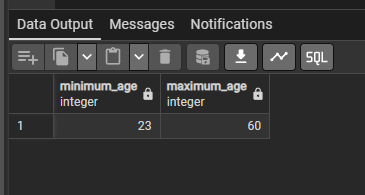

- ***KEY INSIGHT:*** Employee ages range from 23 to 60 years, with no apparent age outliers.

---

# <u>Gender Distribution Analysis:

```sql
SELECT gender, COUNT(*) AS employee_count
FROM hr
WHERE termdate IS NULL
GROUP BY gender
ORDER BY employee_count DESC;
```

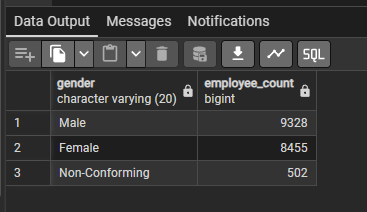

---

# <u>Race/Ethnicity Distribution Analysis:

```sql
SELECT race, COUNT(*) AS employee_count
FROM hr
WHERE termdate IS NULL
GROUP BY race
ORDER BY employee_count DESC;
```

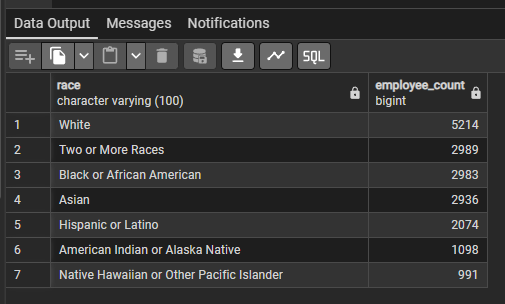

---

# <u>Age Distribution Analysis:

```sql
SELECT
    CASE
        WHEN age >= 20 AND age <= 29 THEN '20s'
        WHEN age >= 30 AND age <= 39 THEN '30s'
        WHEN age >= 40 AND age <= 49 THEN '40s'
        WHEN age >= 50 AND age <= 59 THEN '50s'
        ELSE '60+'
    END AS age_group,
    COUNT(*) AS employee_count
FROM hr
WHERE termdate IS NULL
GROUP BY age_group
ORDER BY age_group;
```

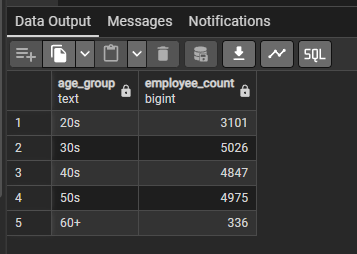

---

# <u>Age Distribution by Gender Analysis:

```sql
SELECT
    CASE
        WHEN age >= 20 AND age <= 29 THEN '20s'
        WHEN age >= 30 AND age <= 39 THEN '30s'
        WHEN age >= 40 AND age <= 49 THEN '40s'
        WHEN age >= 50 AND age <= 59 THEN '50s'
        ELSE '60+'
    END AS age_group, gender,
    COUNT(*) AS employee_count
FROM hr
WHERE termdate IS NULL
GROUP BY age_group, gender
ORDER BY age_group, gender;
```

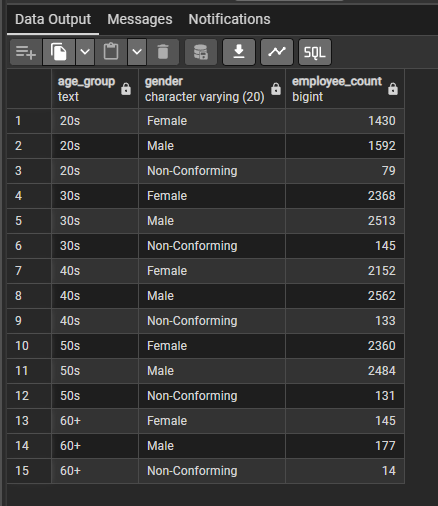

---

# <u>Work Location Distribution Analysis:

```sql
SELECT location, COUNT(*) AS employee_count
FROM hr
WHERE termdate IS NULL
GROUP BY location
ORDER BY employee_count DESC;
```

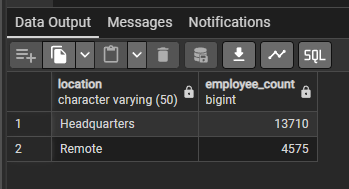

---

# <u>Average Terminated Employee Tenure Analysis:

```sql
SELECT
    ROUND(
        AVG(EXTRACT(YEAR FROM AGE(termdate, hire_date))),
        2
        ) AS avg_terminated_employee_tenure
FROM hr
WHERE termdate IS NOT NULL AND termdate <= CURRENT_DATE;
```

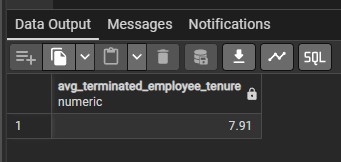

---

# <u>Department-wise Gender Distribution Analysis:

```sql
SELECT department, gender, COUNT(*) AS employee_count
FROM hr
WHERE termdate IS NULL
GROUP BY department, gender
ORDER BY department, gender;
```

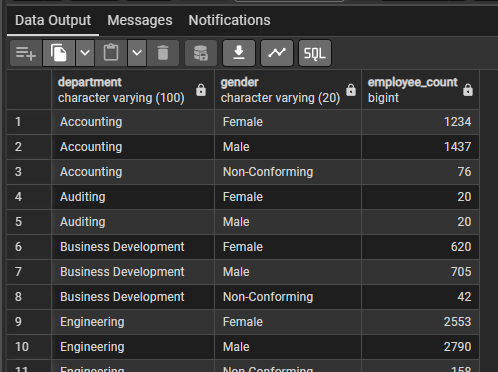

---

# <u>Job Title Distribution Analysis:

```sql
SELECT jobtitle, COUNT(*) AS employee_count
FROM hr
WHERE termdate IS NULL
GROUP BY jobtitle
ORDER BY employee_count DESC;
```

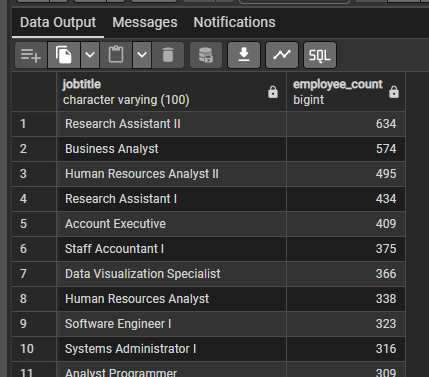

---

# <u>Job Title-wise Gender Distribution Analysis:

```sql
SELECT
    jobtitle,
    gender,
    COUNT(*) AS employee_count
FROM hr
WHERE termdate IS NULL
GROUP BY jobtitle, gender
ORDER BY jobtitle, gender;
```

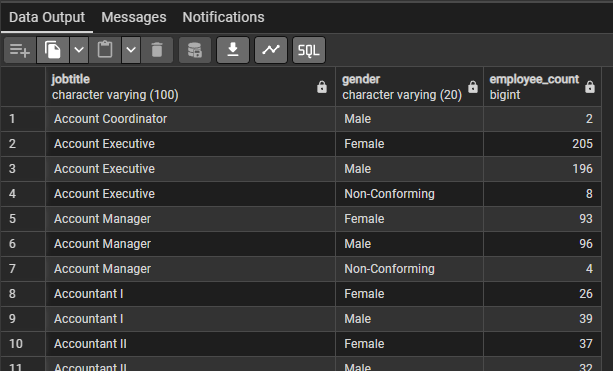

---

# <u>Department Turnover Rate Analysis:

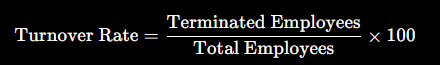

```sql
SELECT
    department,
    ROUND(
        100.0 * (
            SUM(CASE WHEN termdate IS NOT NULL AND termdate <= CURRENT_DATE THEN 1 ELSE 0 END)::numeric
            / COUNT(*)
        ),
        2
    ) AS turnover_rate
FROM hr
GROUP BY department
ORDER BY turnover_rate DESC;
```

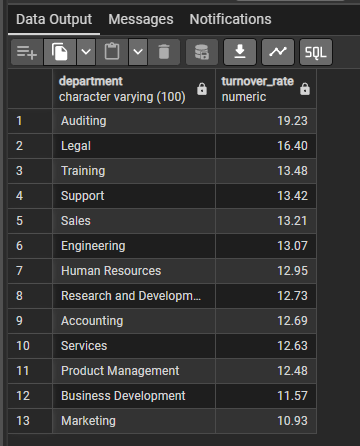

---

# <u>Employee Distribution by City and State:

```sql
SELECT 
	location_city,
	location_state,
	COUNT(*) AS employee_count 
FROM hr
WHERE termdate IS NULL
GROUP BY location_city, location_state
ORDER BY employee_count DESC;
```

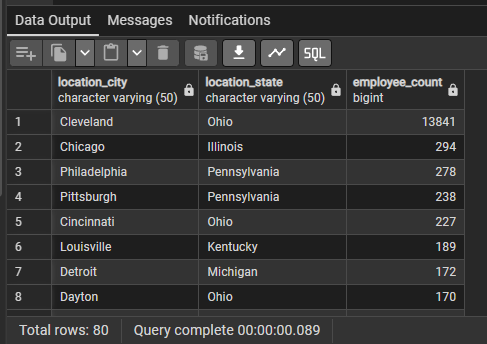

- ***NOTE:*** Aggregated by state for clearer visualization.

```sql
SELECT 
	location_state,
	COUNT(*) AS employee_count 
FROM hr
WHERE termdate IS NULL
GROUP BY location_state
ORDER BY employee_count DESC
```

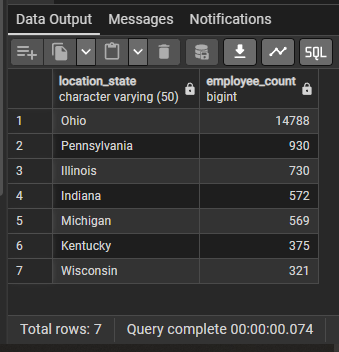

---

# <u>Hiring Cohort Analysis:

```sql
SELECT
	hire_year,
	total_hires,
	total_terminations,
	total_hires - total_terminations AS active_employees,
	ROUND(
		((total_hires - total_terminations)::numeric / total_hires) * 100,
		2
	) AS active_employee_percentage
FROM (
	SELECT
		EXTRACT(YEAR FROM hire_date) AS hire_year,
		COUNT(*) AS total_hires,
		SUM(
			CASE
				WHEN termdate IS NOT NULL AND termdate <= CURRENT_DATE THEN 1
				ELSE 0
			END
		) AS total_terminations
	FROM hr
	GROUP BY EXTRACT(YEAR FROM hire_date)
) AS yearly_hiring_summary
ORDER BY hire_year;
```

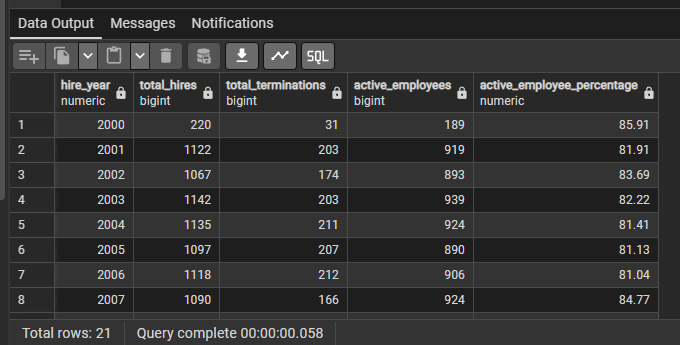

---

# <u>Average Employee Tenure by Department:

```sql
SELECT
	department,
	ROUND(AVG(termdate - hire_date) / 365.0, 0) AS avg_employee_tenure
FROM hr
WHERE termdate IS NOT NULL AND termdate <= CURRENT_DATE
GROUP BY department
ORDER BY avg_employee_tenure DESC;
```

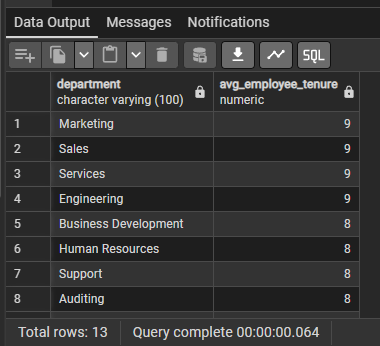

---